# EDA 01 — Evolución Temporal con Fases del Ciclo

Visualiza las tasas de crecimiento interanual de **Ganancias** (Presa) e **Inversión** (Depredador) superpuestas con las bandas de recesión NBER.

**Hipótesis Tapia:** la rentabilidad actúa como indicador adelantado — alcanza su pico y cae *antes* que la inversión.

In [1]:
# ── FLAGS ──────────────────────────────────────────────
SAVE_FIGS = True
# ───────────────────────────────────────────────────────

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

DATA_DIR = Path('../data/raw')
OUT_DIR = Path('../output/notebooks')
if SAVE_FIGS:
    OUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
df = pd.read_csv(DATA_DIR / 'lotka_volterra.csv', index_col=0, parse_dates=True)
print(df.shape)
df.head()

(317, 3)


,PROFITS,INVESTMENT,RECESSION
DATE,,,
1947-03-31,33.466,35.854,0.0
1947-06-30,31.668,34.505,0.0
1947-09-30,31.288,34.911,0.0
1947-12-31,34.123,43.250,0.0
1948-03-31,35.747,47.202,0.0


## Transformación: Tasa de Crecimiento Interanual (YoY %)

Se usa `pct_change(4)` sobre datos trimestrales para obtener variación año contra año,
eliminando el efecto tendencial de largo plazo y dejando visible la dinámica cíclica.

In [4]:
df['PROFITS_YOY'] = df['PROFITS'].pct_change(4) * 100
df['INVEST_YOY'] = df['INVESTMENT'].pct_change(4) * 100
df_plot = df.dropna()

print(f"Período: {df_plot.index[0].date()} → {df_plot.index[-1].date()}")
print(f"Observaciones: {len(df_plot)}")

Período: 1948-03-31 → 2026-03-31
Observaciones: 313


## Gráfico: Series Temporales con Fases del Ciclo

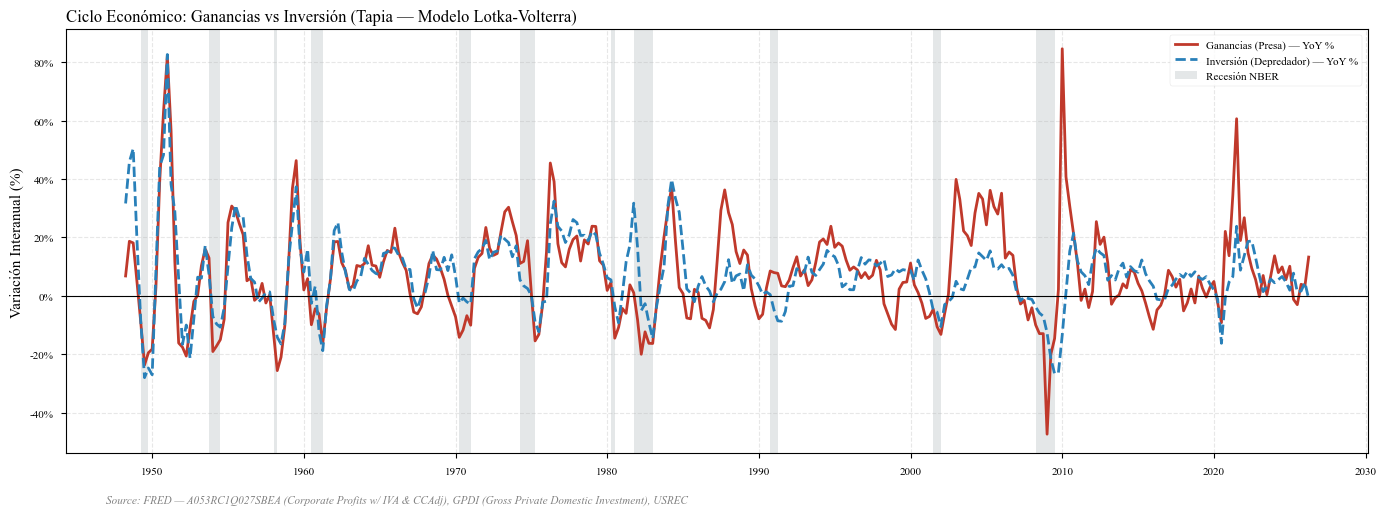

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_plot.index, df_plot['PROFITS_YOY'],
        color='#c0392b', lw=2, label='Ganancias (Presa) — YoY %')
ax.plot(df_plot.index, df_plot['INVEST_YOY'],
        color='#2980b9', lw=2, ls='--', label='Inversión (Depredador) — YoY %')

ax.axhline(0, color='black', lw=0.8)

if 'RECESSION' in df_plot.columns:
    ax.fill_between(df_plot.index, ax.get_ylim()[0], ax.get_ylim()[1],
                    where=df_plot['RECESSION'] > 0.5,
                    transform=ax.get_xaxis_transform(),
                    color='#bdc3c7', alpha=0.4, lw=0, label='Recesión NBER')

ax.set_title('Ciclo Económico: Ganancias vs Inversión (Tapia — Modelo Lotka-Volterra)', loc='left')
ax.set_ylabel('Variación Interanual (%)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.legend(loc='upper right', frameon=True)

fig.text(0.08, -0.02,
         'Source: FRED — A053RC1Q027SBEA (Corporate Profits w/ IVA & CCAdj), GPDI (Gross Private Domestic Investment), USREC',
         fontsize=8, color='gray', style='italic')

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(OUT_DIR / '01_series_temporales.png', dpi=300, bbox_inches='tight')
plt.show()

## Zoom: Ciclos individuales

Zoom en ciclos específicos para verificar visualmente el desfasaje (profits cae antes que investment).

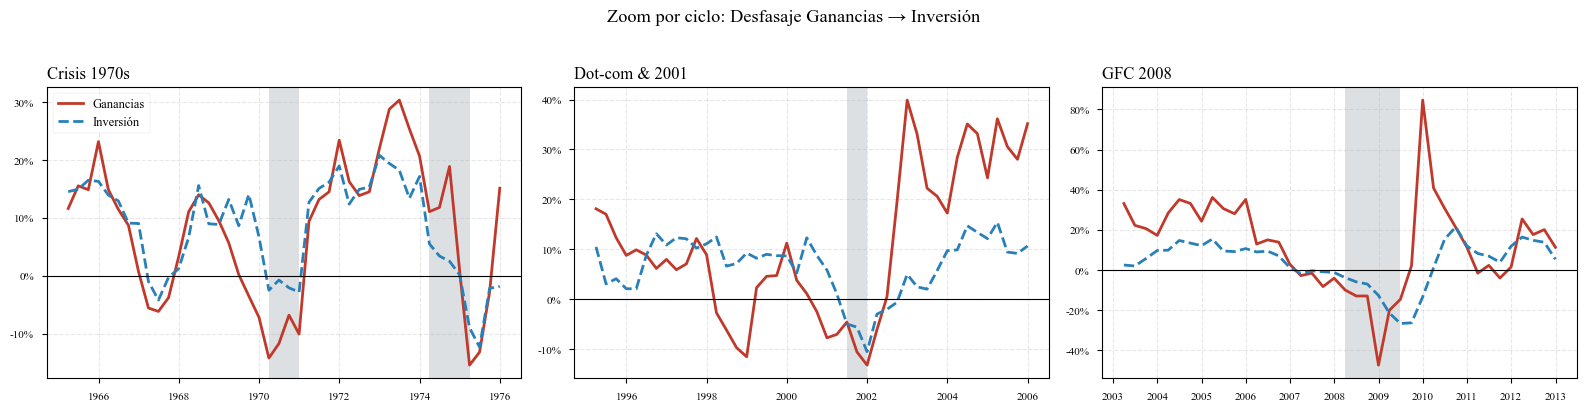

In [6]:
cycles = [
    ('1965', '1975', 'Crisis 1970s'),
    ('1995', '2005', 'Dot-com & 2001'),
    ('2003', '2012', 'GFC 2008'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, (start, end, title) in zip(axes, cycles):
    mask = df_plot.loc[start:end]
    ax.plot(mask.index, mask['PROFITS_YOY'], color='#c0392b', lw=2, label='Ganancias')
    ax.plot(mask.index, mask['INVEST_YOY'], color='#2980b9', lw=2, ls='--', label='Inversión')
    ax.axhline(0, color='black', lw=0.8)
    if 'RECESSION' in mask.columns:
        ax.fill_between(mask.index, 0, 1, where=mask['RECESSION'] > 0.5,
                        transform=ax.get_xaxis_transform(),
                        color='#bdc3c7', alpha=0.5, lw=0)
    ax.set_title(title, loc='left')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f'{y:.0f}%'))

axes[0].legend(fontsize=9)
plt.suptitle('Zoom por ciclo: Desfasaje Ganancias → Inversión', y=1.02)
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(OUT_DIR / '01_zoom_ciclos.png', dpi=300, bbox_inches='tight')
plt.show()